# Step 1 - Explore dataset
Loading the dataset into a table (a DataFrame). And showing the first rows and the column names

In [297]:
import pandas

df = pandas.read_csv("titanic.csv")
df.head()

,pnumber,pclass,survived,name,age,embarked,home.dest,room,ticket,boat,sex
0,1,1st,1,"Allen, Miss Elisabeth Walton",29.0000,Southampton,"St Louis, MO",B-5,24160 L221,2,female
1,2,1st,0,"Allison, Miss Helen Loraine",2.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female
2,3,1st,0,"Allison, Mr Hudson Joshua Creighton",30.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,-135,male
3,4,1st,0,"Allison, Mrs Hudson J.C. (Bessie Waldo Daniels)",25.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female
4,5,1st,1,"Allison, Master Hudson Trevor",0.9167,Southampton,"Montreal, PQ / Chesterville, ON",C22,NaN,11,male


### Identify missing values (which columns have gaps?).

In [253]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pnumber    1313 non-null   int64  
 1   pclass     1313 non-null   str    
 2   survived   1313 non-null   int64  
 3   name       1313 non-null   str    
 4   age        633 non-null    float64
 5   embarked   821 non-null    str    
 6   home.dest  754 non-null    str    
 7   room       77 non-null     str    
 8   ticket     69 non-null     str    
 9   boat       347 non-null    str    
 10  sex        1313 non-null   str    
dtypes: float64(1), int64(2), str(8)
memory usage: 113.0 KB


Transform data to useful data

In [254]:
df["pclass"] = df["pclass"].map({"1st":1, "2nd":2, "3rd":3}).astype(int)
df.head()

,pnumber,pclass,survived,name,age,embarked,home.dest,room,ticket,boat,sex
0,1,1,1,"Allen, Miss Elisabeth Walton",29.0000,Southampton,"St Louis, MO",B-5,24160 L221,2,female
1,2,1,0,"Allison, Miss Helen Loraine",2.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female
2,3,1,0,"Allison, Mr Hudson Joshua Creighton",30.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,-135,male
3,4,1,0,"Allison, Mrs Hudson J.C. (Bessie Waldo Daniels)",25.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female
4,5,1,1,"Allison, Master Hudson Trevor",0.9167,Southampton,"Montreal, PQ / Chesterville, ON",C22,NaN,11,male


## Calculating survival percentage

In [255]:
survival_percentage = df["survived"].mean() * 100
print(f"Survival percentage: {survival_percentage:.2f}%")

Survival percentage: 34.20%


## Calculating survival chance per ticket class

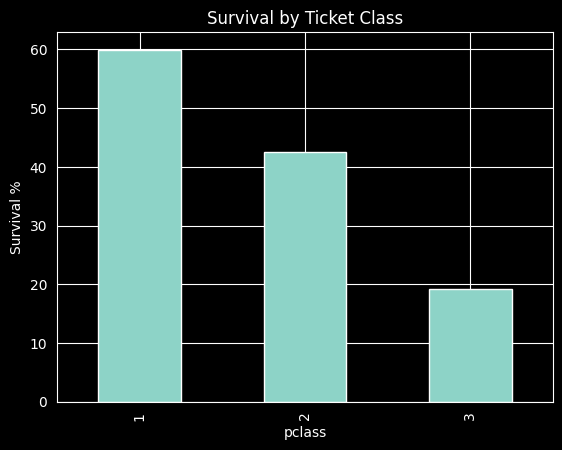

pclass
1    59.937888
2    42.500000
3    19.268636
Name: survived, dtype: float64


In [256]:
import matplotlib.pyplot as plt

class_survival = df.groupby("pclass")["survived"].mean() * 100
class_survival.plot(kind="bar")

plt.ylabel("Survival %")
plt.title("Survival by Ticket Class")
plt.show()

print(class_survival)

## Calculating survival chance per gender

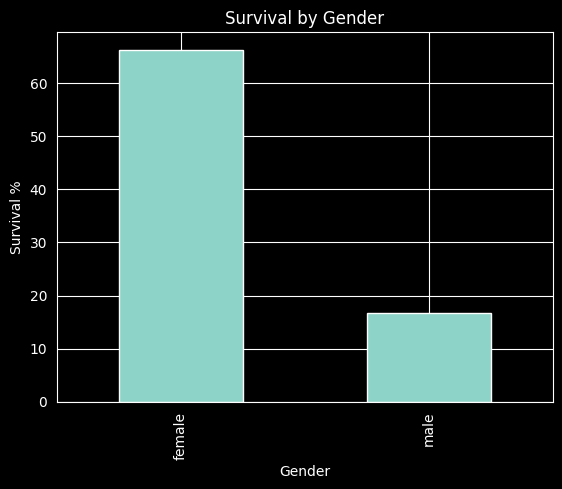

sex
female    66.306695
male      16.705882
Name: survived, dtype: float64


In [257]:
gender_survival = df.groupby("sex")["survived"].mean() * 100
gender_survival.plot(kind="bar")

plt.ylabel("Survival %")
plt.xlabel("Gender")
plt.title("Survival by Gender")
plt.show()

print(gender_survival)

## Calculating survival chance per age group

Creating age groups in steps of 10 years

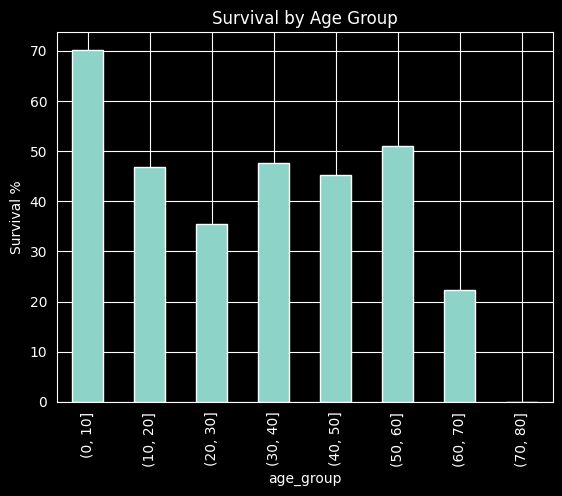

age_group
(0, 10]     70.212766
(10, 20]    46.938776
(20, 30]    35.532995
(30, 40]    47.692308
(40, 50]    45.161290
(50, 60]    51.063830
(60, 70]    22.222222
(70, 80]     0.000000
Name: survived, dtype: float64


In [258]:
df["age_group"] = pandas.cut(df["age"], bins=[0,10,20,30,40,50,60,70,80,90,100])

age_survival = df.groupby("age_group")["survived"].mean() * 100
age_survival.plot(kind="bar")

plt.ylabel("Survival %")
plt.title("Survival by Age Group")
plt.show()

print(age_survival)

# Step 2 - Building a first model

In [259]:
import pandas as pd

x = df[["pclass", "sex", "age"]].copy()
x

,pclass,sex,age
0,1,female,29.0000
1,1,female,2.0000
2,1,male,30.0000
3,1,female,25.0000
4,1,male,0.9167
...,...,...,...
1308,3,male,NaN
1309,3,male,NaN
1310,3,male,NaN
1311,3,female,NaN


In [260]:
y = df["survived"]
y

0       1
1       0
2       0
3       0
4       1
       ..
1308    0
1309    0
1310    0
1311    0
1312    0
Name: survived, Length: 1313, dtype: int64

In [261]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Fill missing ages with median age & Convert "male" "female" to boolean
x["age"] = x["age"].fillna(x["age"].median())
X = pd.get_dummies(x, columns=["sex"], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

accuracy = model.score(x_test, y_test)
print(f"Model accuracy: {accuracy*100:.2f}%")

(1050, 3)
(263, 3)
(1050,)
(263,)
Model accuracy: 82.13%


## Stupid Baseline 1: Predict Nobody Survives

In [262]:
from sklearn.metrics import accuracy_score

baseline_pred = [0] * len(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline (nobody survives) accuracy: {baseline_accuracy*100:.2f}%")

Baseline (nobody survives) accuracy: 65.02%


## Stupid baseline 2: Predict Everyone Survives

In [263]:
baseline_pred_all_survive = [1] * len(y_test)
baseline_accuracy_all = accuracy_score(y_test, baseline_pred_all_survive)

print(f"Baseline (everyone survives) accuracy: {baseline_accuracy_all*100:.2f}%")

Baseline (everyone survives) accuracy: 34.98%


## Stupid baseline 3: Predict Most Common Class

In [264]:
most_common_class = y_train.mode()[0]
baseline_pred_majority = [most_common_class] * len(y_test)
baseline_majority_accuracy = accuracy_score(y_test, baseline_pred_majority)

print(f"Baseline (majority class) accuracy: {baseline_majority_accuracy*100:.2f}%")

Baseline (majority class) accuracy: 65.02%


# Accuracy conclusion:
- Stupid baseline (everyone dies): 63.88%
- Baseline (everyone survives) accuracy: 36.12%
- Baseline (majority class) accuracy: 63.88%


- Model: 81.37%

81.37% − 63.88% = 17.49% improvement


## Model predictions & info

In [296]:
new_passenger = pd.DataFrame({
    "pclass": [1],
    "age": [39],
    "sex_male": [1]
})

prediction = model.predict(new_passenger)
probability = model.predict_proba(new_passenger)

print("Prediction:", prediction[0])
print("Survival probability:", probability[0][1])

Prediction: 0
Survival probability: 0.5


## Decision weight

In [277]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False))

sex_male    0.459381
age         0.272680
pclass      0.267939
dtype: float64
